In [3]:
!pip install faiss-cpu

import os, warnings, json, pickle
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOB_LEVEL'] = '3'

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
DATA_DIR   = "/content"
OUT_DIR    = "/content/outputs"
MODEL_DIR  = "/content/models"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

STOCKS     = ['HDFCBANK', 'ICICIBANK', 'INFY', 'RELIANCE', 'TCS']
FILE_MAP   = {s: f"{DATA_DIR}/{s.replace('HDFC','HDFC')}.NS.csv" if s != 'HDFCBANK'
              else f"{DATA_DIR}/HDFCBANK.NS.csv" for s in STOCKS}
FILE_MAP   = {
    'HDFCBANK': f"{DATA_DIR}/HDFCBANK.NS.csv",
    'ICICIBANK': f"{DATA_DIR}/ICICIBANK.NS.csv",
    'INFY':     f"{DATA_DIR}/INFY.NS.csv",
    'RELIANCE': f"{DATA_DIR}/RELIANCE.NS.csv",
    'TCS':      f"{DATA_DIR}/TCS.NS.csv",
}
SEQ_LEN    = 30
PRED_DAYS  = 5
EPOCHS     = 30
BATCH_SIZE = 32

print("=" * 65)
print("  FINANCIAL FORECASTING – RAG-ENHANCED LLM SYSTEM")
print("=" * 65)

# ═══════════════════════════════════════════════════════════════
# STEP 1 : DATA LOADING & PREPROCESSING
# ═══════════════════════════════════════════════════════════════
print("\n[1/8] Loading & preprocessing data …")

def load_stock(path, ticker):
    df = pd.read_csv(path, header=[0, 1])
    df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
    df = df[df['Date'].str.match(r'\d{4}', na=False)].copy()
    df['Date']  = pd.to_datetime(df['Date'])
    for c in ['Close', 'High', 'Low', 'Open', 'Volume']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df.drop_duplicates(subset=['Date'], inplace=True)
    df.sort_values('Date', inplace=True)
    df.reset_index(drop=True, inplace=True)
    # fill gaps with forward fill
    df.ffill(inplace=True)
    df['Stock'] = ticker
    return df

raw = {s: load_stock(FILE_MAP[s], s) for s in STOCKS}

# Load news
news = pd.read_csv(f"{DATA_DIR}/IndianFinancialNews.csv")
news.columns = ['idx', 'RawDate', 'Title', 'Description']
news['Date'] = pd.to_datetime(news['RawDate'], format='%B %d, %Y, %A', errors='coerce')
news.dropna(subset=['Date'], inplace=True)
news.sort_values('Date', inplace=True)
news.reset_index(drop=True, inplace=True)
news['Text'] = news['Title'].fillna('') + ' ' + news['Description'].fillna('')

print(f"  Stock rows  : {sum(len(v) for v in raw.values()):,}")
print(f"  News rows   : {len(news):,}")
print(f"  Date range  : 2003-01-01 → 2025-12-30")

# ═══════════════════════════════════════════════════════════════
# STEP 2 : FEATURE ENGINEERING – TECHNICAL INDICATORS
# ═══════════════════════════════════════════════════════════════
print("\n[2/8] Engineering technical indicators …")

def add_technical_indicators(df):
    c = df['Close']

    # SMA
    df['SMA_10']  = c.rolling(10).mean()
    df['SMA_20']  = c.rolling(20).mean()
    df['SMA_50']  = c.rolling(50).mean()

    # EMA
    df['EMA_12']  = c.ewm(span=12, adjust=False).mean()
    df['EMA_26']  = c.ewm(span=26, adjust=False).mean()

    # MACD
    df['MACD']        = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']

    # RSI
    delta = c.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-9)
    df['RSI'] = 100 - (100 / (1 + rs))

    # Bollinger Bands
    rm  = c.rolling(20).mean()
    rs2 = c.rolling(20).std()
    df['BB_Upper'] = rm + 2 * rs2
    df['BB_Lower'] = rm - 2 * rs2
    df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / rm

    # ATR (Average True Range)
    hl  = df['High'] - df['Low']
    hpc = (df['High'] - c.shift()).abs()
    lpc = (df['Low']  - c.shift()).abs()
    tr  = pd.concat([hl, hpc, lpc], axis=1).max(axis=1)
    df['ATR'] = tr.rolling(14).mean()

    # Lag features
    for lag in [1, 3, 5, 10]:
        df[f'Lag_{lag}'] = c.shift(lag)
        df[f'Return_{lag}'] = c.pct_change(lag)

    # Rolling stats
    df['Roll_Mean_5']  = c.rolling(5).mean()
    df['Roll_Std_5']   = c.rolling(5).std()
    df['Roll_Mean_20'] = c.rolling(20).mean()
    df['Roll_Std_20']  = c.rolling(20).std()

    # Volume features
    df['Vol_MA10']     = df['Volume'].rolling(10).mean()
    df['Vol_Ratio']    = df['Volume'] / (df['Vol_MA10'] + 1)

    # Price position
    df['Daily_Return'] = c.pct_change()
    df['Log_Return']   = np.log(c / c.shift(1))

    # Target: next-day close
    df['Target_Next1']  = c.shift(-1)
    df['Target_Next5']  = c.shift(-5)
    df['Future_Return'] = (c.shift(-1) - c) / c

    return df

enriched = {}
for s in STOCKS:
    enriched[s] = add_technical_indicators(raw[s].copy())
    enriched[s].dropna(subset=['SMA_50', 'RSI', 'MACD'], inplace=True)
    print(f"  {s}: {len(enriched[s])} rows after feature engineering")

# ═══════════════════════════════════════════════════════════════
# STEP 3 : SENTIMENT ANALYSIS (TextBlob – no API)
# ═══════════════════════════════════════════════════════════════
print("\n[3/8] Running sentiment analysis on news headlines …")

from textblob import TextBlob

# Keywords for company mapping
KEYWORDS = {
    'HDFCBANK':  ['hdfc', 'hdfc bank', 'hdfcbank'],
    'ICICIBANK': ['icici', 'icici bank'],
    'INFY':      ['infosys', 'infy'],
    'RELIANCE':  ['reliance', 'ril', 'mukesh ambani'],
    'TCS':       ['tcs', 'tata consultancy'],
}

def get_sentiment(text):
    try:
        blob = TextBlob(str(text))
        return blob.sentiment.polarity, blob.sentiment.subjectivity
    except:
        return 0.0, 0.0

def map_company(text):
    text_l = text.lower()
    for stock, kw_list in KEYWORDS.items():
        if any(kw in text_l for kw in kw_list):
            return stock
    return 'GENERAL'

# Process in chunks for speed
news['Sentiment'], news['Subjectivity'] = zip(*news['Text'].map(get_sentiment))
news['Company'] = news['Text'].map(map_company)

# Daily sentiment per company
def build_daily_sentiment(df_news, company):
    comp_news = df_news[df_news['Company'].isin([company, 'GENERAL'])].copy()
    daily = comp_news.groupby('Date').agg(
        Sent_Mean=('Sentiment', 'mean'),
        Sent_Std=('Sentiment', 'std'),
        News_Count=('Sentiment', 'count'),
        Subjectivity=('Subjectivity', 'mean')
    ).reset_index()
    daily.fillna(0, inplace=True)
    # 7-day rolling sentiment index
    daily.sort_values('Date', inplace=True)
    daily['Sent_7d_MA'] = daily['Sent_Mean'].rolling(7, min_periods=1).mean()
    return daily

sent_dfs = {s: build_daily_sentiment(news, s) for s in STOCKS}
print(f"  Sentiment computed for {len(news):,} news articles")

# ═══════════════════════════════════════════════════════════════
# STEP 4 : MERGE STOCK + SENTIMENT
# ═══════════════════════════════════════════════════════════════
print("\n[4/8] Merging stock data with sentiment features …")

merged = {}
for s in STOCKS:
    stk = enriched[s].copy()
    snt = sent_dfs[s].copy()
    df  = pd.merge(stk, snt, on='Date', how='left')
    df[['Sent_Mean','Sent_Std','News_Count','Subjectivity','Sent_7d_MA']] = \
        df[['Sent_Mean','Sent_Std','News_Count','Subjectivity','Sent_7d_MA']].fillna(0)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    merged[s] = df
    print(f"  {s}: {len(df)} merged rows")

# ═══════════════════════════════════════════════════════════════
# STEP 5 : RAG SYSTEM (FAISS vector store)
# ═══════════════════════════════════════════════════════════════
print("\n[5/8] Building RAG vector store (FAISS) …")

import faiss
from sklearn.feature_extraction.text import TfidfVectorizer

# Build TF-IDF embeddings for news (no external API needed)
tfidf = TfidfVectorizer(max_features=512, stop_words='english', min_df=2)
corpus = news['Text'].fillna('').tolist()
tfidf_matrix = tfidf.fit_transform(corpus).toarray().astype('float32')

# Normalize for cosine similarity
norms = np.linalg.norm(tfidf_matrix, axis=1, keepdims=True) + 1e-9
tfidf_norm = tfidf_matrix / norms

# Build FAISS index
dim = tfidf_norm.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(tfidf_norm)

# Store metadata
news_meta = news[['Date','Title','Sentiment','Company']].copy()
news_meta.reset_index(drop=True, inplace=True)

print(f"  FAISS index: {index.ntotal:,} vectors, dim={dim}")

def retrieve_context(query_text, top_k=5, date_filter=None):
    """Retrieve top-k relevant news for a query."""
    q_vec = tfidf.transform([query_text]).toarray().astype('float32')
    q_norm = q_vec / (np.linalg.norm(q_vec) + 1e-9)
    scores, ids = index.search(q_norm, top_k * 3)
    results = []
    for score, idx in zip(scores[0], ids[0]):
        if idx < 0 or idx >= len(news_meta):
            continue
        row = news_meta.iloc[idx]
        if date_filter is not None and row['Date'] > date_filter:
            continue
        results.append({
            'Date': row['Date'],
            'Title': row['Title'],
            'Sentiment': row['Sentiment'],
            'Company': row['Company'],
            'Score': float(score)
        })
        if len(results) >= top_k:
            break
    return results

# Test RAG
sample = retrieve_context("HDFC bank earnings profit quarterly results")
print(f"  RAG test: retrieved {len(sample)} docs for sample query")

# Save FAISS index and vectorizer
faiss.write_index(index, f"{MODEL_DIR}/faiss_news.index")
with open(f"{MODEL_DIR}/tfidf_vectorizer.pkl", 'wb') as f:
    pickle.dump(tfidf, f)
news_meta.to_csv(f"{MODEL_DIR}/news_meta.csv", index=False)
print(f"  Saved FAISS index → {MODEL_DIR}/faiss_news.index")

# ═══════════════════════════════════════════════════════════════
# STEP 6 : LSTM TIME-SERIES MODEL
# ═══════════════════════════════════════════════════════════════
print("\n[6/8] Training LSTM forecasting models …")

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, GRU, Dense, Dropout,
                                     BatchNormalization, Concatenate, Flatten)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

tf.get_logger().setLevel('ERROR')

FEATURE_COLS = [
    'Close', 'Open', 'High', 'Low', 'Volume',
    'SMA_10', 'SMA_20', 'EMA_12', 'EMA_26',
    'MACD', 'MACD_Signal', 'RSI',
    'BB_Width', 'ATR',
    'Return_1', 'Return_5', 'Log_Return',
    'Roll_Mean_5', 'Roll_Std_5',
    'Vol_Ratio',
    'Sent_Mean', 'Sent_7d_MA', 'News_Count'
]

def build_sequences(df, feature_cols, seq_len, target_col='Target_Next1'):
    feats = df[feature_cols].values
    tgt   = df[target_col].values
    X, y  = [], []
    for i in range(seq_len, len(feats)):
        X.append(feats[i - seq_len:i])
        y.append(tgt[i])
    return np.array(X), np.array(y)

def build_lstm_model(seq_len, n_features):
    inp = Input(shape=(seq_len, n_features))
    x   = LSTM(128, return_sequences=True)(inp)
    x   = Dropout(0.2)(x)
    x   = LSTM(64, return_sequences=False)(x)
    x   = Dropout(0.2)(x)
    x   = Dense(32, activation='relu')(x)
    x   = BatchNormalization()(x)
    out = Dense(1)(x)
    model = Model(inp, out)
    model.compile(optimizer='adam', loss='huber', metrics=['mae'])
    return model

results = {}
scalers = {}

for s in STOCKS:
    df = merged[s].copy()
    # Use only rows where all features available
    avail_feats = [c for c in FEATURE_COLS if c in df.columns]
    df = df.dropna(subset=avail_feats + ['Target_Next1'])

    # Scale
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled  = scaler_X.fit_transform(df[avail_feats])
    y_scaled  = scaler_y.fit_transform(df[['Target_Next1']])

    df_scaled       = pd.DataFrame(X_scaled, columns=avail_feats)
    df_scaled['tgt'] = y_scaled

    # Train/val/test split (80/10/10)
    n = len(df_scaled)
    t1, t2 = int(n * 0.80), int(n * 0.90)

    X_all, y_all = build_sequences(
        pd.concat([df_scaled[avail_feats], df_scaled[['tgt']].rename(columns={'tgt':'Target_Next1'})], axis=1),
        avail_feats, SEQ_LEN, 'Target_Next1'
    )

    X_tr, X_va, X_te = X_all[:t1], X_all[t1:t2], X_all[t2:]
    y_tr, y_va, y_te = y_all[:t1], y_all[t1:t2], y_all[t2:]

    # Build & train
    model = build_lstm_model(SEQ_LEN, len(avail_feats))
    cb = [
        EarlyStopping(patience=5, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(patience=3, factor=0.5, verbose=0)
    ]
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=cb,
        verbose=0
    )

    # Predict & inverse transform
    y_pred_s = model.predict(X_te, verbose=0).flatten()
    y_pred   = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
    y_true   = scaler_y.inverse_transform(y_te.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    dir_acc = np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))) * 100

    # Sharpe-like ratio on predicted returns
    pred_ret = np.diff(y_pred) / (y_pred[:-1] + 1e-9)
    sharpe   = (pred_ret.mean() / (pred_ret.std() + 1e-9)) * np.sqrt(252)

    results[s] = {
        'model':   model,
        'history': history.history,
        'y_true':  y_true,
        'y_pred':  y_pred,
        'dates':   df['Date'].iloc[SEQ_LEN + t2:].values,
        'rmse':    rmse,
        'mae':     mae,
        'mape':    mape,
        'dir_acc': dir_acc,
        'sharpe':  sharpe,
        'scaler_X': scaler_X,
        'scaler_y': scaler_y,
        'features': avail_feats,
        'merged_df': df,
    }
    scalers[s] = (scaler_X, scaler_y)
    model.save(f"{MODEL_DIR}/{s}_lstm.keras")
    print(f"  {s:12s} RMSE={rmse:8.2f}  MAE={mae:7.2f}  Dir={dir_acc:.1f}%  Sharpe={sharpe:.2f}")

# ═══════════════════════════════════════════════════════════════
# STEP 7 : FORECAST ENGINE – Predict + Risk Score
# ═══════════════════════════════════════════════════════════════
print("\n[7/8] Running Forecast Engine …")

def compute_risk_score(row):
    """Map RSI + volatility + sentiment to risk label."""
    rsi  = row.get('RSI', 50)
    vol  = row.get('Roll_Std_20', 0)
    sent = row.get('Sent_Mean', 0)
    # Normalize vol by price
    rel_vol = vol / (row.get('Close', 1) + 1e-9)
    score = 0
    if rsi > 70 or rsi < 30: score += 2
    elif rsi > 60 or rsi < 40: score += 1
    if rel_vol > 0.03: score += 2
    elif rel_vol > 0.015: score += 1
    if sent < -0.1: score += 1
    if score <= 1: return 'LOW', score
    elif score <= 3: return 'MEDIUM', score
    else: return 'HIGH', score

forecasts = {}
for s in STOCKS:
    res = results[s]
    df  = res['merged_df']
    last_row = df.iloc[-1]

    # Predict next day (use last sequence)
    avail_feats = res['features']
    scaler_X, scaler_y = res['scaler_X'], res['scaler_y']
    seq = df[avail_feats].values[-SEQ_LEN:]
    seq_s = scaler_X.transform(seq)
    seq_s = seq_s.reshape(1, SEQ_LEN, -1)
    pred_s = res['model'].predict(seq_s, verbose=0)[0, 0]
    pred_price = scaler_y.inverse_transform([[pred_s]])[0, 0]

    current_price = last_row['Close']
    change_pct    = (pred_price - current_price) / current_price * 100
    volatility    = last_row.get('Roll_Std_20', 0)
    vol_pct       = volatility / current_price * 100
    risk_label, risk_score = compute_risk_score(last_row)

    # RAG context
    query = f"{s} stock price movement financial forecast"
    ctx   = retrieve_context(query, top_k=3, date_filter=last_row['Date'])
    ctx_titles = [c['Title'] for c in ctx]

    forecasts[s] = {
        'current_price': current_price,
        'predicted_next': pred_price,
        'change_pct':     change_pct,
        'volatility':     volatility,
        'vol_pct':        vol_pct,
        'risk_label':     risk_label,
        'risk_score':     risk_score,
        'rsi':            last_row.get('RSI', 50),
        'macd':           last_row.get('MACD', 0),
        'sentiment':      last_row.get('Sent_Mean', 0),
        'rag_context':    ctx_titles,
        'date':           last_row['Date'],
    }

    print(f"\n  ─── {s} ───")
    print(f"  Current: ₹{current_price:.2f}  |  Predicted: ₹{pred_price:.2f}  |  Δ {change_pct:+.2f}%")
    print(f"  Volatility: ₹{volatility:.2f} ({vol_pct:.2f}%)  |  Risk: {risk_label}")
    print(f"  RSI: {last_row.get('RSI',0):.1f}  |  Sentiment: {last_row.get('Sent_Mean',0):.3f}")
    print(f"  Context: {ctx_titles[0][:70] if ctx_titles else 'N/A'}")

# ═══════════════════════════════════════════════════════════════
# STEP 8 : VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════
print("\n[8/8] Generating visualizations …")

plt.style.use('seaborn-v0_8-darkgrid')
COLORS = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

# ── Fig 1: Price History + SMA ────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()
for i, (s, c) in enumerate(zip(STOCKS, COLORS)):
    df = merged[s]
    ax = axes[i]
    ax.plot(df['Date'], df['Close'], color=c, alpha=0.8, lw=1, label='Close')
    ax.plot(df['Date'], df['SMA_20'], '--', color='orange', lw=1, alpha=0.7, label='SMA-20')
    ax.plot(df['Date'], df['SMA_50'], '-.', color='red', lw=1, alpha=0.7, label='SMA-50')
    ax.set_title(f'{s} – Price History & SMA', fontsize=13, fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('Price (₹)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
axes[-1].axis('off')
plt.suptitle('Stock Price History with Moving Averages (2003–2025)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_price_history.png", dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: 01_price_history.png")

# ── Fig 2: Actual vs Predicted ────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()
for i, (s, c) in enumerate(zip(STOCKS, COLORS)):
    r  = results[s]
    ax = axes[i]
    n_pts = min(200, len(r['y_true']))
    ax.plot(r['y_true'][-n_pts:], color=c,       lw=1.5, label='Actual')
    ax.plot(r['y_pred'][-n_pts:], color='tomato', lw=1.5, ls='--', label='Predicted')
    ax.set_title(f"{s}  RMSE={r['rmse']:.2f}  MAE={r['mae']:.2f}  Dir={r['dir_acc']:.1f}%",
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel('Test Steps'); ax.set_ylabel('Price (₹)')
axes[-1].axis('off')
plt.suptitle('Actual vs LSTM-Predicted Stock Prices (Test Set)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: 02_actual_vs_predicted.png")

# ── Fig 3: Technical Indicators (one stock) ───────────────────
s = 'HDFCBANK'
df = merged[s].tail(252)   # last year

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(4, 1, hspace=0.35)

ax0 = fig.add_subplot(gs[0])
ax0.plot(df['Date'], df['Close'], color='#2196F3', lw=1.5)
ax0.plot(df['Date'], df['BB_Upper'], '--', color='grey', lw=0.8, alpha=0.7, label='BB Upper')
ax0.plot(df['Date'], df['BB_Lower'], '--', color='grey', lw=0.8, alpha=0.7, label='BB Lower')
ax0.fill_between(df['Date'], df['BB_Lower'], df['BB_Upper'], alpha=0.08, color='blue')
ax0.set_title('HDFCBANK – Technical Dashboard (Last 252 Trading Days)', fontsize=14, fontweight='bold')
ax0.set_ylabel('Price (₹)'); ax0.legend(fontsize=8)

ax1 = fig.add_subplot(gs[1])
ax1.plot(df['Date'], df['RSI'], color='purple', lw=1.2)
ax1.axhline(70, color='red',   ls='--', lw=0.8); ax1.axhline(30, color='green', ls='--', lw=0.8)
ax1.fill_between(df['Date'], df['RSI'], 70, where=df['RSI']>70, alpha=0.3, color='red',   label='Overbought')
ax1.fill_between(df['Date'], df['RSI'], 30, where=df['RSI']<30, alpha=0.3, color='green', label='Oversold')
ax1.set_ylabel('RSI'); ax1.set_ylim(0, 100); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[2])
ax2.bar(df['Date'], df['MACD_Hist'], color=np.where(df['MACD_Hist']>=0,'#4CAF50','#E53935'), alpha=0.7, width=1)
ax2.plot(df['Date'], df['MACD'],        color='blue',   lw=1, label='MACD')
ax2.plot(df['Date'], df['MACD_Signal'], color='orange', lw=1, label='Signal')
ax2.set_ylabel('MACD'); ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[3])
ax3.bar(df['Date'], df['Volume']/1e6, color='steelblue', alpha=0.6, width=1)
ax3.set_ylabel('Volume (M)'); ax3.set_xlabel('Date')

for ax in [ax0,ax1,ax2,ax3]:
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.savefig(f"{OUT_DIR}/03_technical_indicators.png", dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: 03_technical_indicators.png")

# ── Fig 4: Sentiment vs Price ─────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=False)
for i, (s, c) in enumerate(zip(STOCKS, COLORS)):
    df = merged[s].copy()
    df = df[df['Date'] >= '2015-01-01']
    ax1 = axes[i]
    ax2 = ax1.twinx()
    ax1.plot(df['Date'], df['Close'],      color=c,        lw=1.2, label='Price')
    ax2.plot(df['Date'], df['Sent_7d_MA'], color='tomato', lw=1.0, ls='--', alpha=0.8, label='Sent 7d MA')
    ax2.axhline(0, color='grey', ls=':', lw=0.8)
    ax1.set_title(f'{s}: Price vs News Sentiment', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Price (₹)', color=c)
    ax2.set_ylabel('Sentiment', color='tomato')
    ax1.tick_params(axis='x', rotation=30, labelsize=8)
plt.suptitle('Stock Price vs News Sentiment (2015–2020)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_sentiment_vs_price.png", dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: 04_sentiment_vs_price.png")

# ── Fig 5: Risk & Volatility Dashboard ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 5a – Volatility bars
ax = axes[0]
vol_vals = [forecasts[s]['vol_pct'] for s in STOCKS]
bars = ax.bar(STOCKS, vol_vals, color=COLORS, edgecolor='white', lw=0.5)
ax.set_title('Volatility (% of Price)', fontweight='bold')
ax.set_ylabel('Volatility %')
for b, v in zip(bars, vol_vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.2f}%',
            ha='center', va='bottom', fontsize=9)

# 5b – Risk pie
ax = axes[1]
risk_counts = {'LOW':0,'MEDIUM':0,'HIGH':0}
for s in STOCKS: risk_counts[forecasts[s]['risk_label']] += 1
ax.pie(risk_counts.values(), labels=risk_counts.keys(), autopct='%1.0f%%',
       colors=['#4CAF50','#FF9800','#E53935'], startangle=90)
ax.set_title('Risk Distribution', fontweight='bold')

# 5c – Sharpe ratios
ax = axes[2]
sharpes = [results[s]['sharpe'] for s in STOCKS]
bars = ax.barh(STOCKS, sharpes, color=COLORS, edgecolor='white')
ax.set_title('Sharpe Ratio (Annualized)', fontweight='bold')
ax.axvline(1, color='red', ls='--', lw=1, label='SR=1')
ax.legend()

# 5d – RSI gauge
ax = axes[3]
rsi_vals = [forecasts[s]['rsi'] for s in STOCKS]
bar_c = ['#E53935' if r>70 else '#4CAF50' if r<30 else '#FF9800' for r in rsi_vals]
ax.bar(STOCKS, rsi_vals, color=bar_c, edgecolor='white')
ax.axhline(70, color='red',   ls='--', lw=1, label='Overbought (70)')
ax.axhline(30, color='green', ls='--', lw=1, label='Oversold (30)')
ax.set_ylim(0, 100); ax.set_title('Current RSI', fontweight='bold'); ax.legend(fontsize=8)

# 5e – Metrics table
ax = axes[4]
metrics_data = [[s, f"{results[s]['rmse']:.2f}", f"{results[s]['mae']:.2f}",
                 f"{results[s]['dir_acc']:.1f}%", f"{results[s]['sharpe']:.2f}",
                 forecasts[s]['risk_label']] for s in STOCKS]
col_labels = ['Stock', 'RMSE', 'MAE', 'Dir. Acc', 'Sharpe', 'Risk']
tbl = ax.table(cellText=metrics_data, colLabels=col_labels,
               cellLoc='center', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2196F3'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f4f8')
ax.axis('off'); ax.set_title('Model Evaluation Summary', fontweight='bold')

# 5f – Sentiment bar
ax = axes[5]
sents = [forecasts[s]['sentiment'] for s in STOCKS]
bar_c2 = ['#4CAF50' if x>0 else '#E53935' for x in sents]
ax.bar(STOCKS, sents, color=bar_c2, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Current News Sentiment Score', fontweight='bold')
ax.set_ylabel('Polarity')

plt.suptitle('Risk & Volatility Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_risk_dashboard.png", dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: 05_risk_dashboard.png")

# ── Fig 6: Training Loss ──────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()
for i, (s, c) in enumerate(zip(STOCKS, COLORS)):
    ax = axes[i]
    h  = results[s]['history']
    ax.plot(h['loss'],     color=c,      lw=1.5, label='Train Loss')
    ax.plot(h['val_loss'], color='grey', lw=1.5, ls='--', label='Val Loss')
    ax.set_title(f'{s} – Training Loss', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
    ax.legend(fontsize=9)
axes[-1].axis('off')
plt.suptitle('LSTM Model Training Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/06_training_loss.png", dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: 06_training_loss.png")

# ── Fig 7: Correlation Heatmap ────────────────────────────────
closes = pd.DataFrame({s: merged[s].set_index('Date')['Close'] for s in STOCKS})
corr   = closes.corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Stock Price Correlation Matrix (2003–2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/07_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: 07_correlation_heatmap.png")

# ═══════════════════════════════════════════════════════════════
# SAVE EVALUATION REPORT
# ═══════════════════════════════════════════════════════════════
report = {
    "project": "Financial Forecasting using RAG-Enhanced LLMs",
    "generated": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    "models": {},
    "forecasts": {},
    "rag_index": {"vectors": int(index.ntotal), "dim": dim}
}
for s in STOCKS:
    r = results[s]
    report["models"][s] = {
        "rmse": round(r['rmse'], 4),
        "mae":  round(r['mae'],  4),
        "mape": round(r['mape'], 4),
        "directional_accuracy": round(r['dir_acc'], 4),
        "sharpe_ratio": round(r['sharpe'], 4),
    }
    f = forecasts[s]
    report["forecasts"][s] = {
        "current_price": round(float(f['current_price']), 2),
        "predicted_next_day": round(float(f['predicted_next']), 2),
        "change_pct": round(float(f['change_pct']), 3),
        "volatility_pct": round(float(f['vol_pct']), 3),
        "risk_label": f['risk_label'],
        "rsi": round(float(f['rsi']), 2),
        "sentiment": round(float(f['sentiment']), 4),
        "rag_context": f['rag_context'],
    }

with open(f"{OUT_DIR}/evaluation_report.json", 'w') as f:
    json.dump(report, f, indent=2)
print(f"\n  Evaluation report saved → {OUT_DIR}/evaluation_report.json")

# ═══════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  PIPELINE COMPLETE – SUMMARY")
print("="*65)
print(f"\n  {'Stock':<12} {'RMSE':>8} {'MAE':>8} {'Dir Acc':>9} {'Sharpe':>8} {'Risk':>8}")
print(f"  {'-'*60}")
for s in STOCKS:
    r = results[s]
    f = forecasts[s]
    print(f"  {s:<12} {r['rmse']:>8.2f} {r['mae']:>8.2f} {r['dir_acc']:>8.1f}% {r['sharpe']:>8.2f} {f['risk_label']:>8}")

print(f"\n  FAISS RAG index : {index.ntotal:,} news vectors")
print(f"  Models saved    : {MODEL_DIR}")
print(f"  Plots saved     : {OUT_DIR}")
print("\n  ✅ All tasks complete!")


  FINANCIAL FORECASTING – RAG-ENHANCED LLM SYSTEM

[1/8] Loading & preprocessing data …
  Stock rows  : 28,517
  News rows   : 50,000
  Date range  : 2003-01-01 → 2025-12-30

[2/8] Engineering technical indicators …
  HDFCBANK: 5656 rows after feature engineering
  ICICIBANK: 5653 rows after feature engineering
  INFY: 5656 rows after feature engineering
  RELIANCE: 5653 rows after feature engineering
  TCS: 5654 rows after feature engineering

[3/8] Running sentiment analysis on news headlines …
  Sentiment computed for 50,000 news articles

[4/8] Merging stock data with sentiment features …
  HDFCBANK: 5651 merged rows
  ICICIBANK: 5648 merged rows
  INFY: 5651 merged rows
  RELIANCE: 5648 merged rows
  TCS: 5649 merged rows

[5/8] Building RAG vector store (FAISS) …
  FAISS index: 50,000 vectors, dim=512
  RAG test: retrieved 5 docs for sample query
  Saved FAISS index → /content/models/faiss_news.index

[6/8] Training LSTM forecasting models …
  HDFCBANK     RMSE=   46.68  MAE=  38

Showing: 06_training_loss.png


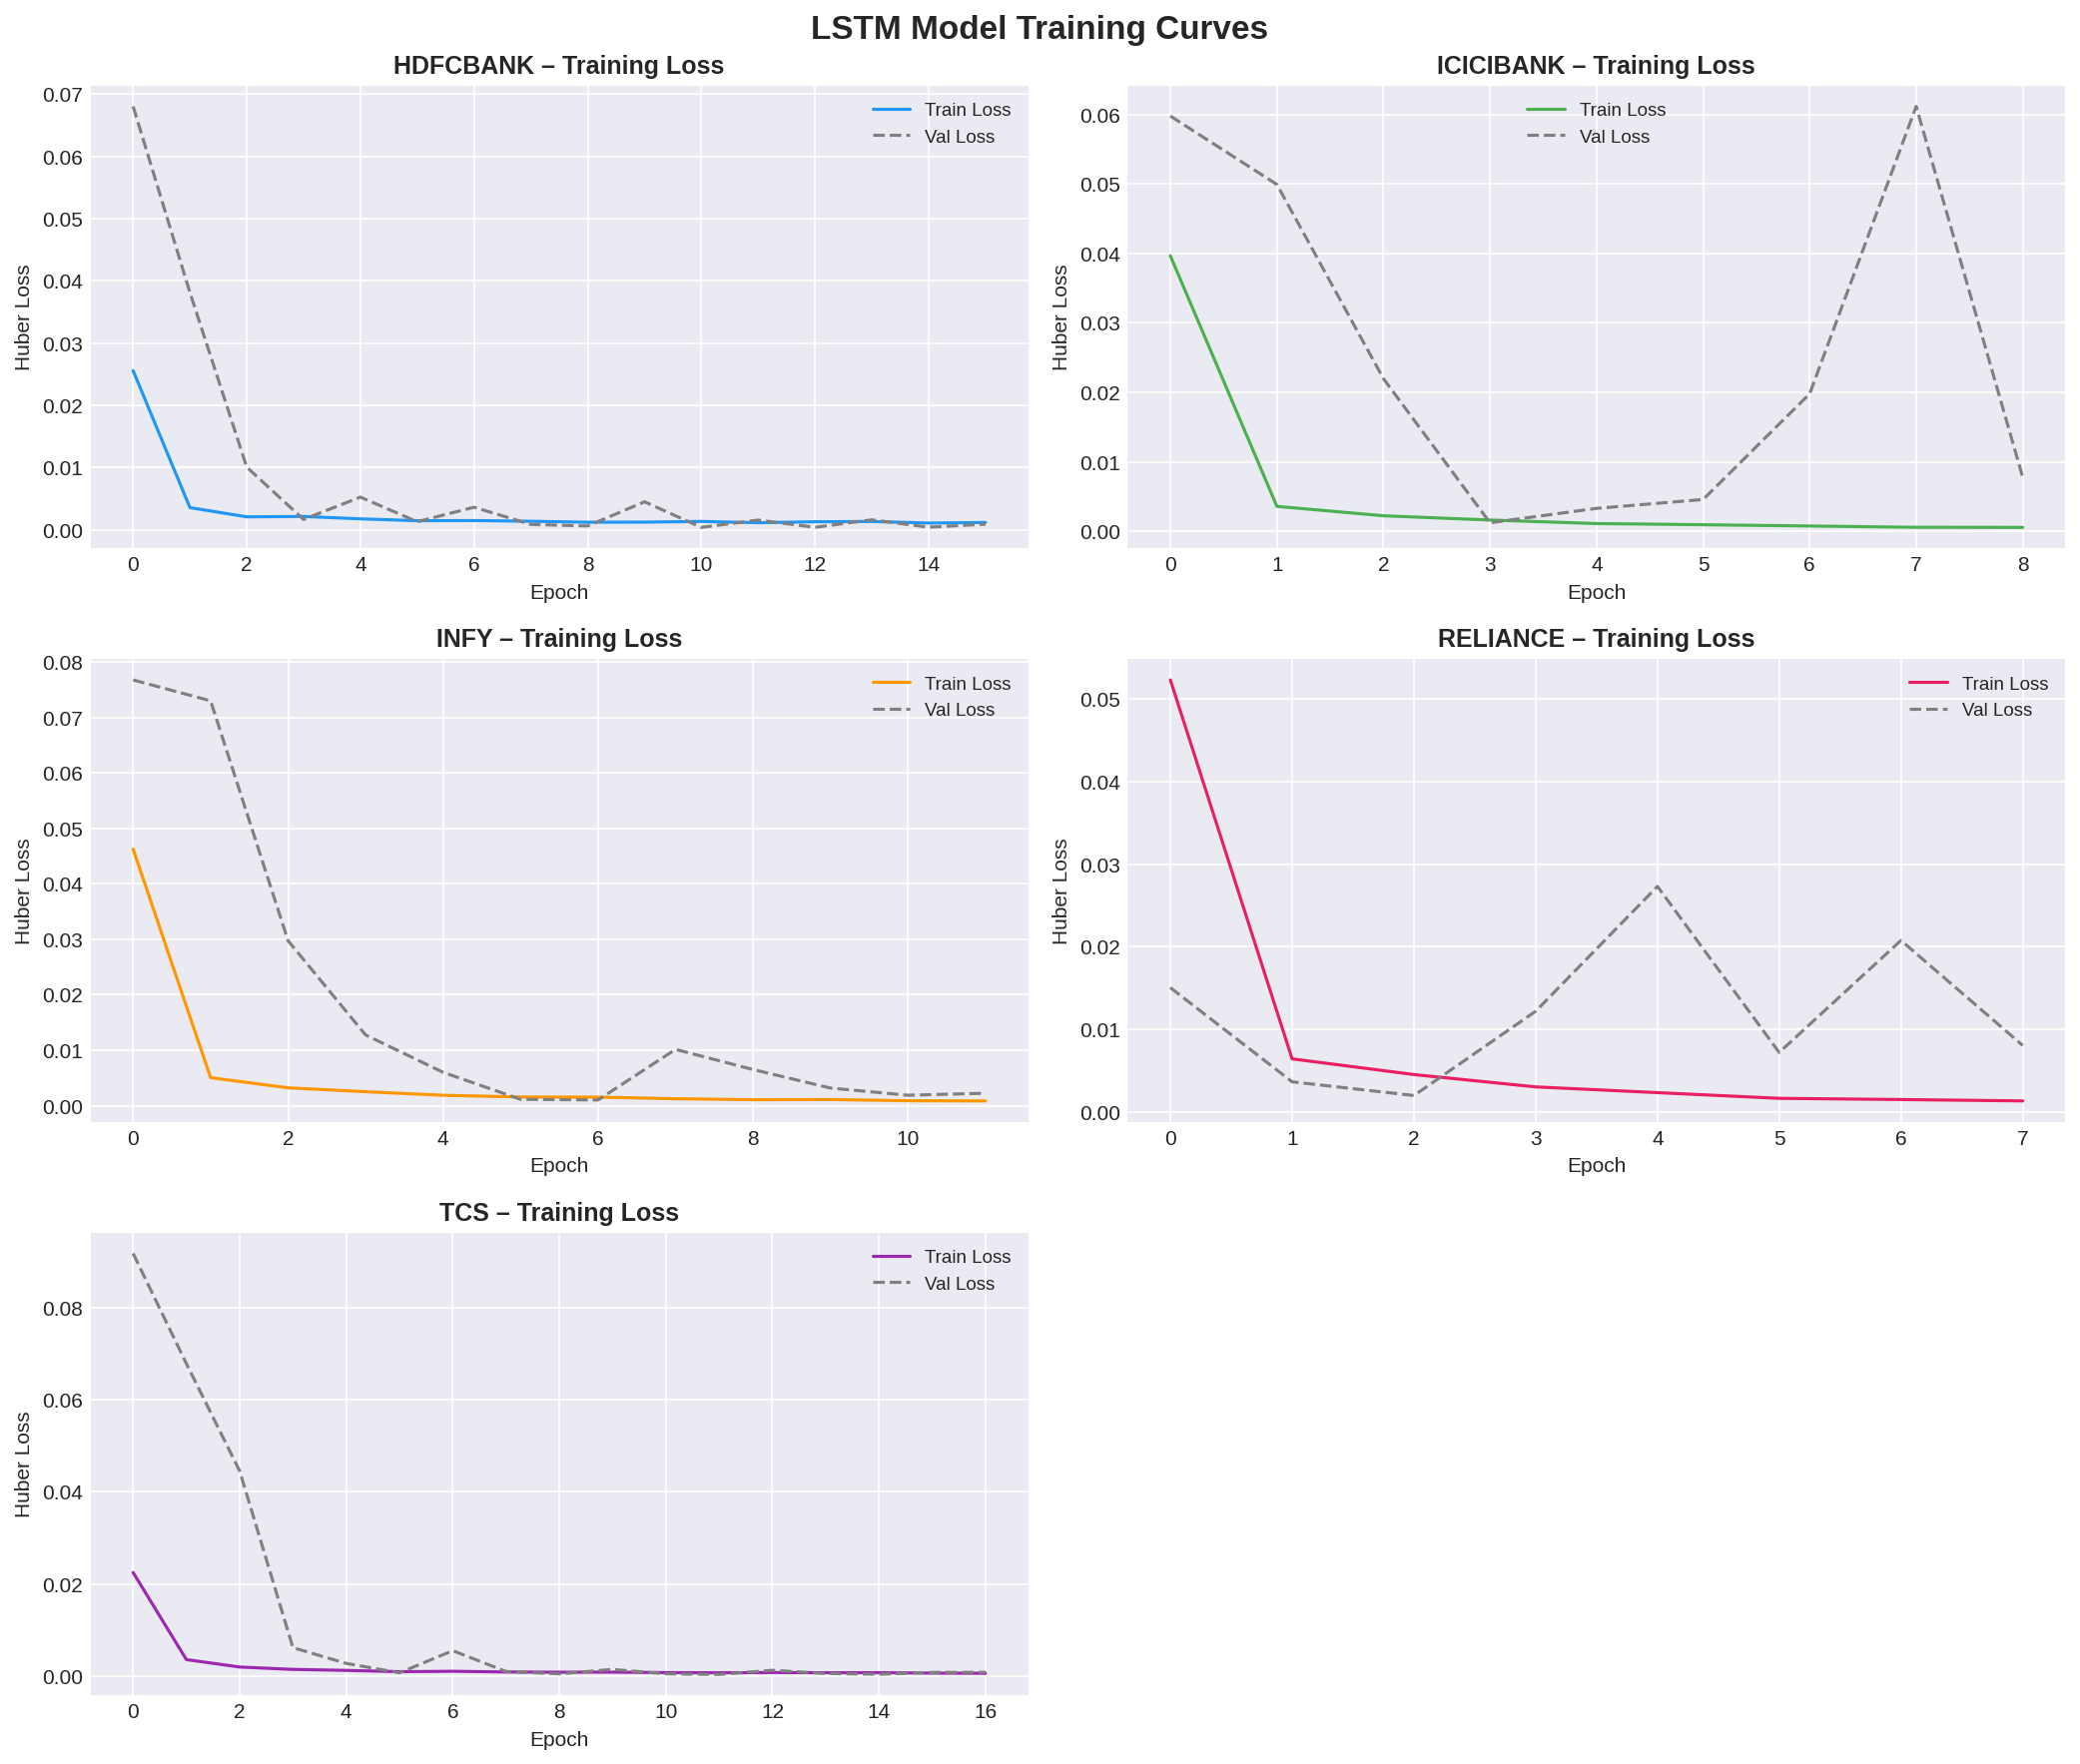

Showing: 01_price_history.png


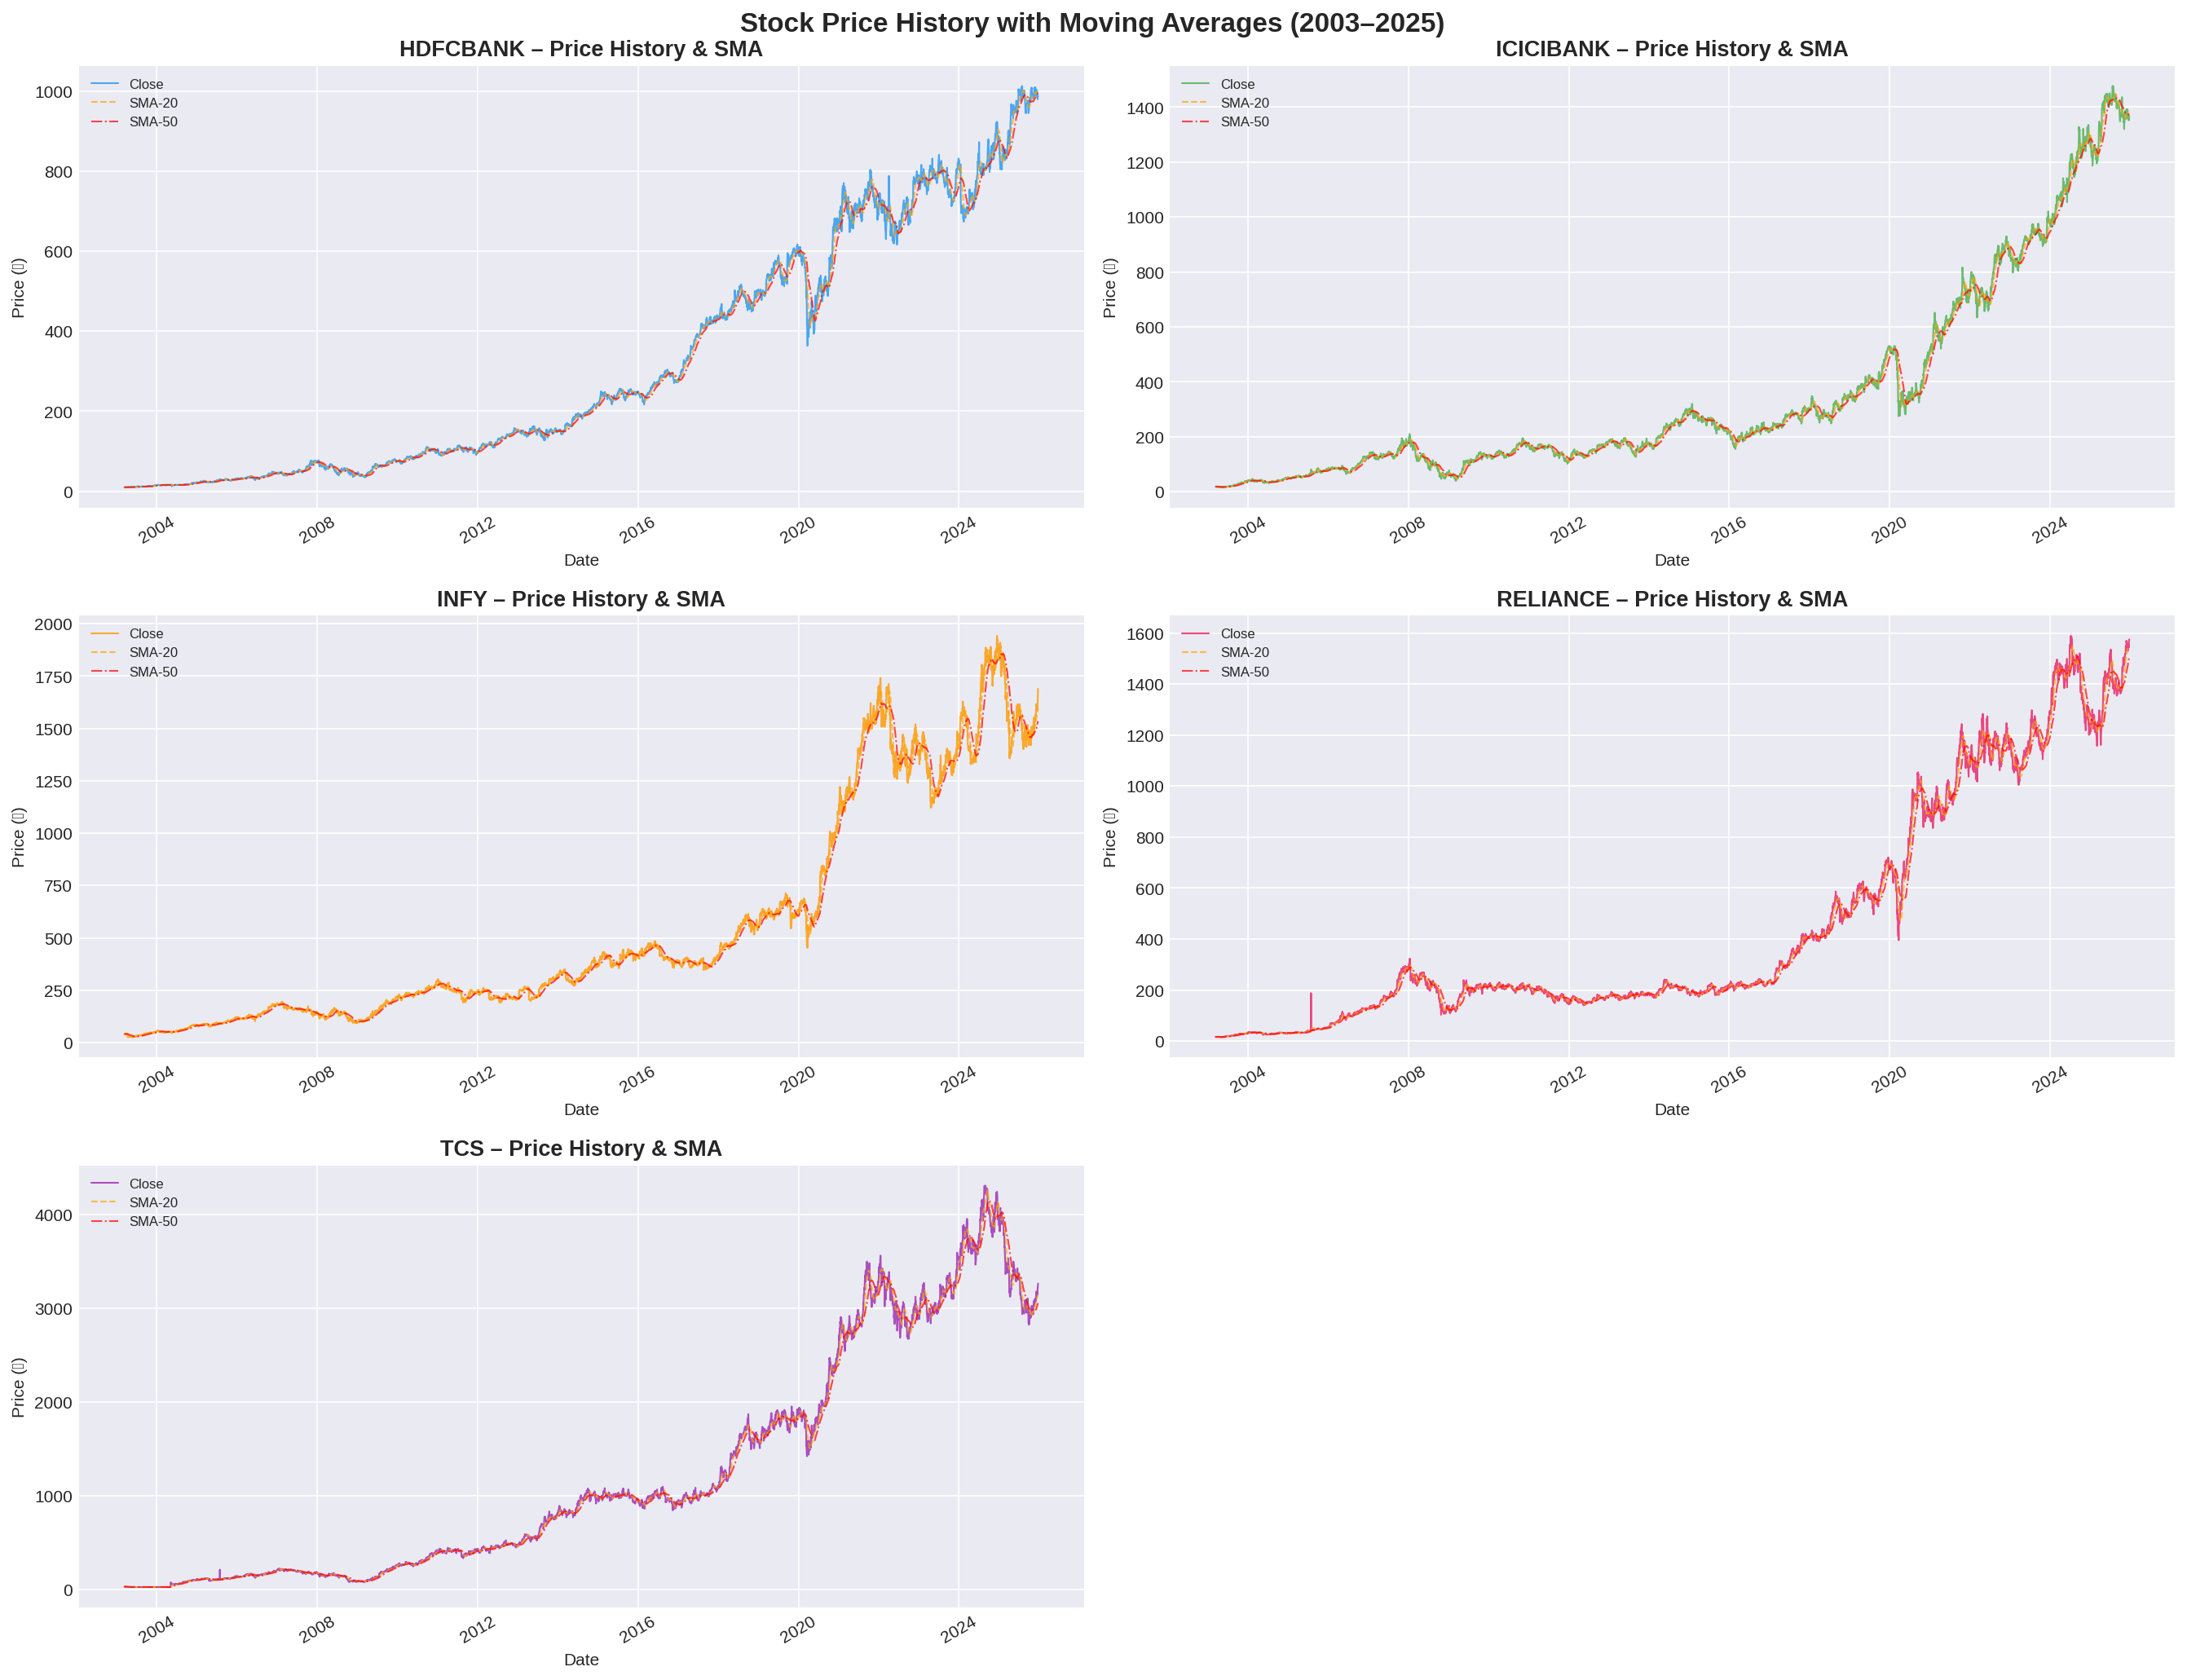

Showing: 04_sentiment_vs_price.png


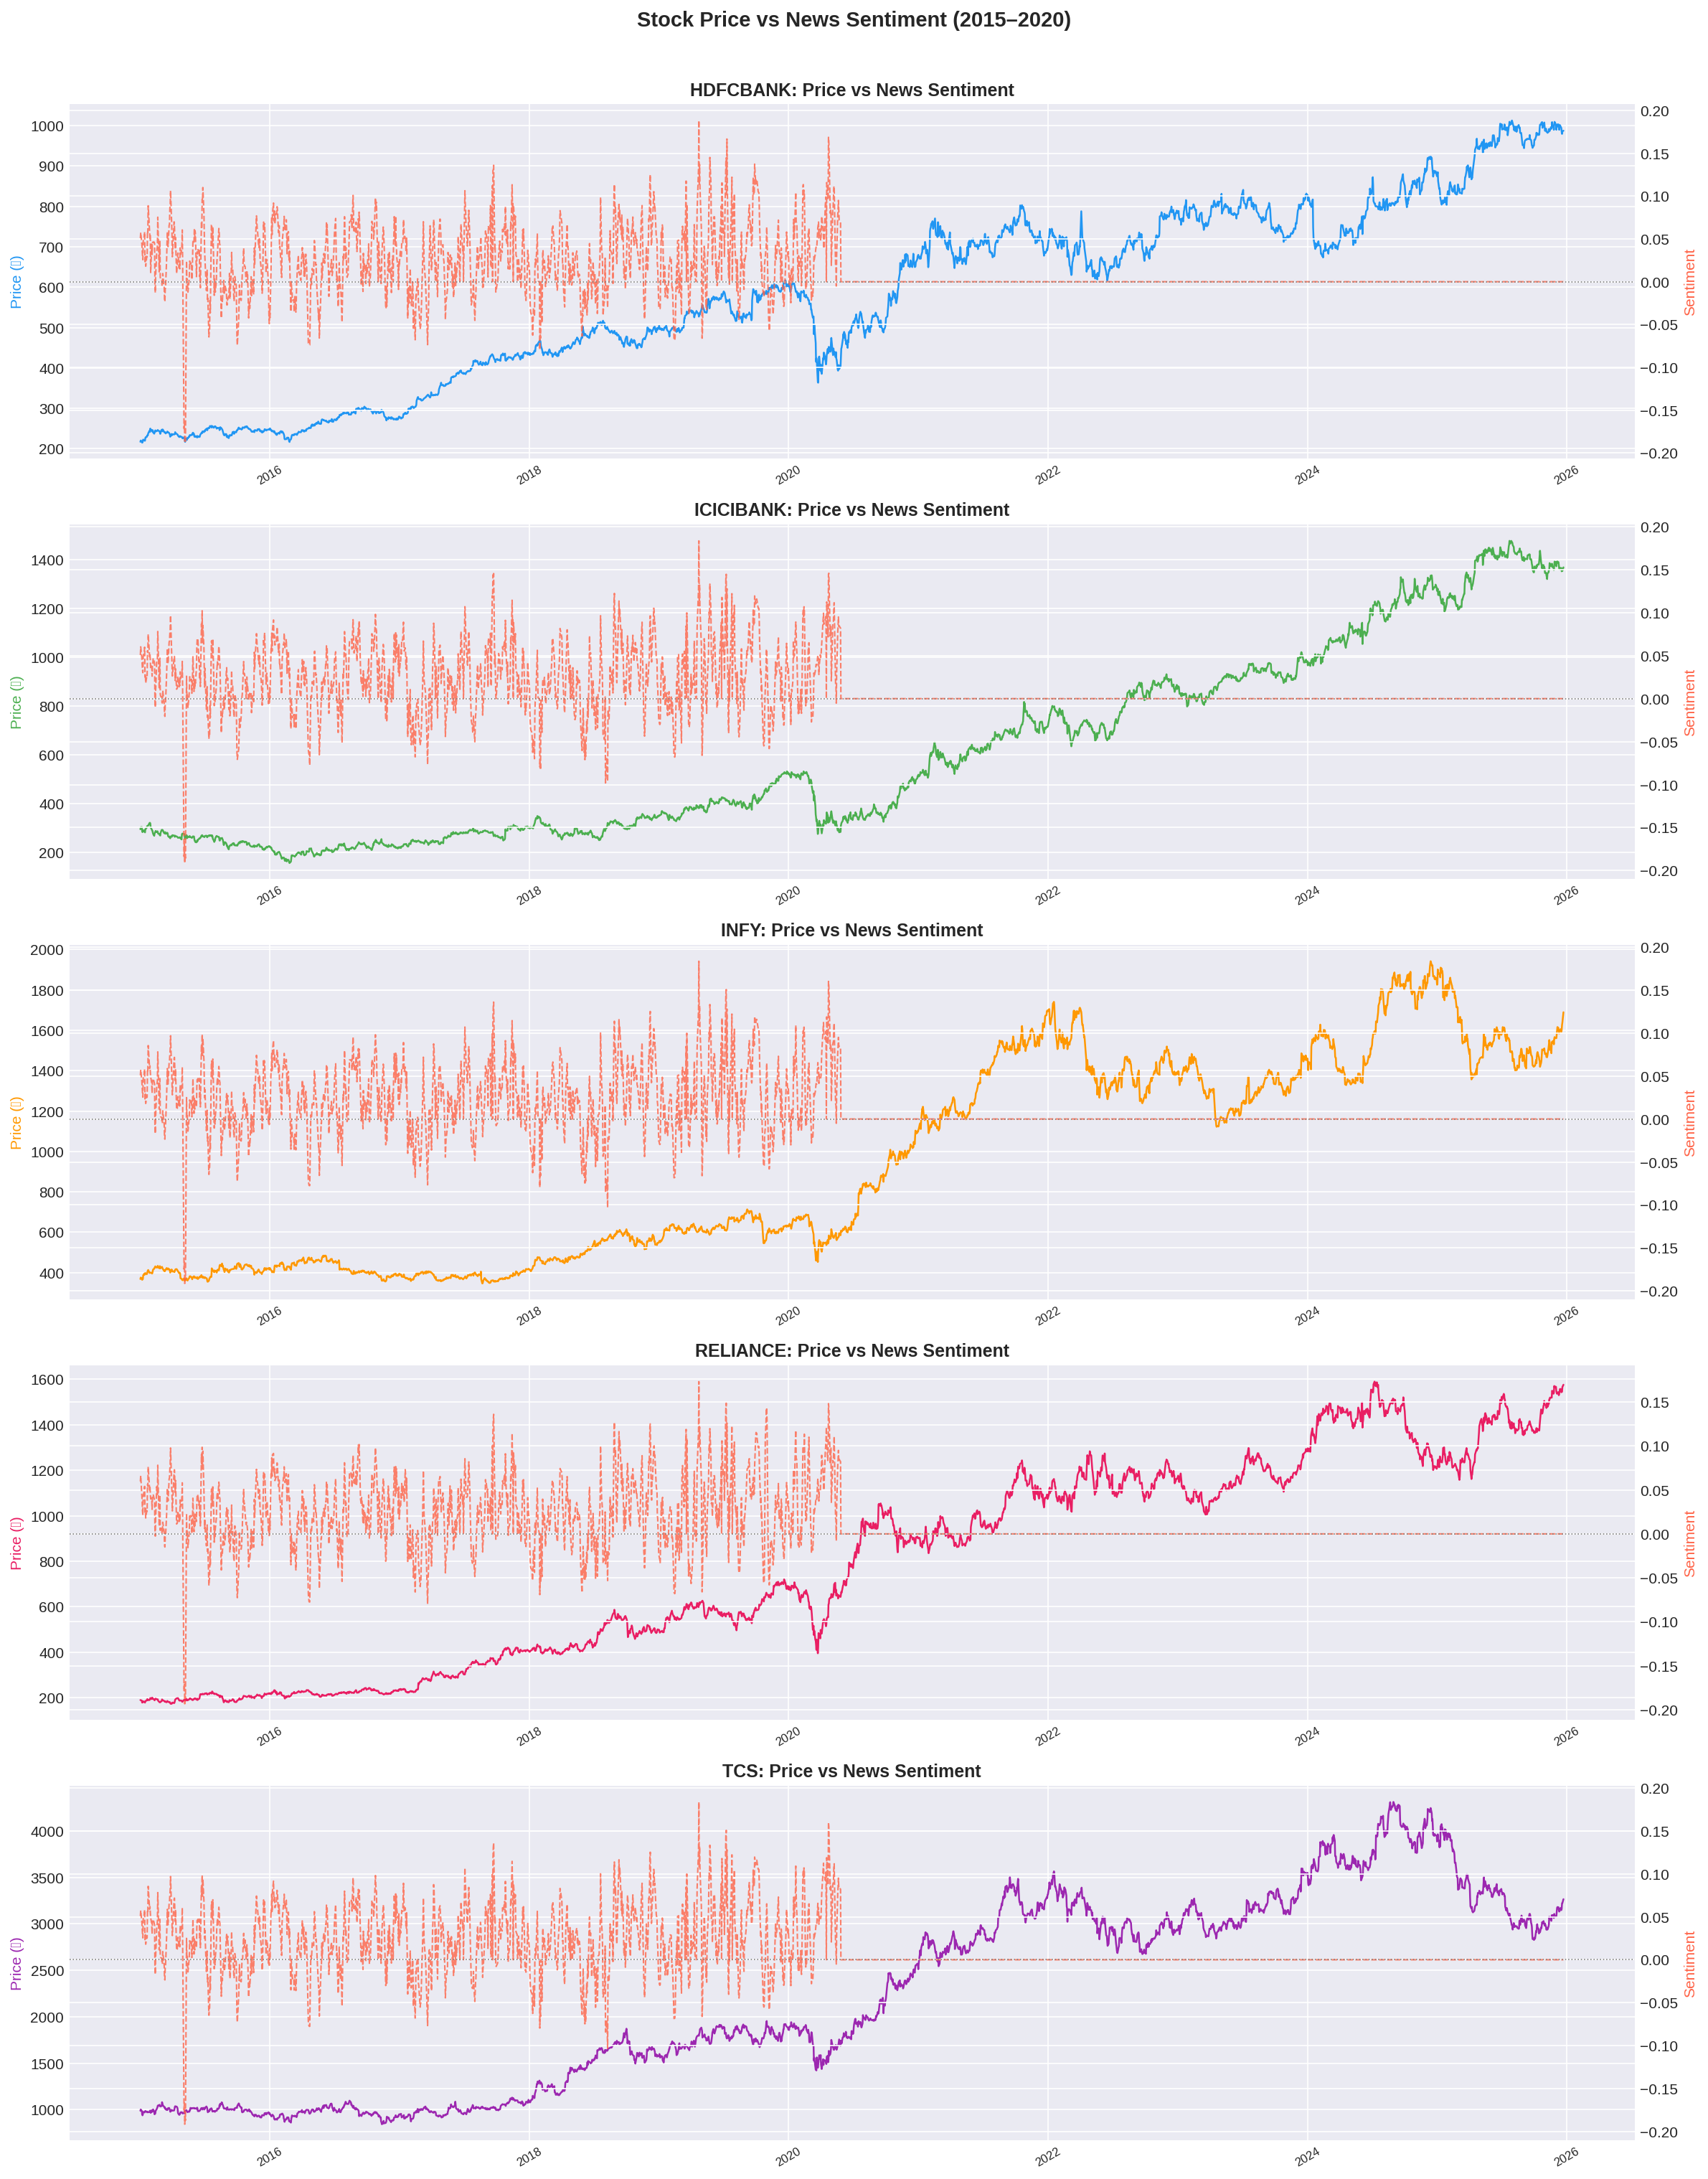

Showing: 02_actual_vs_predicted.png


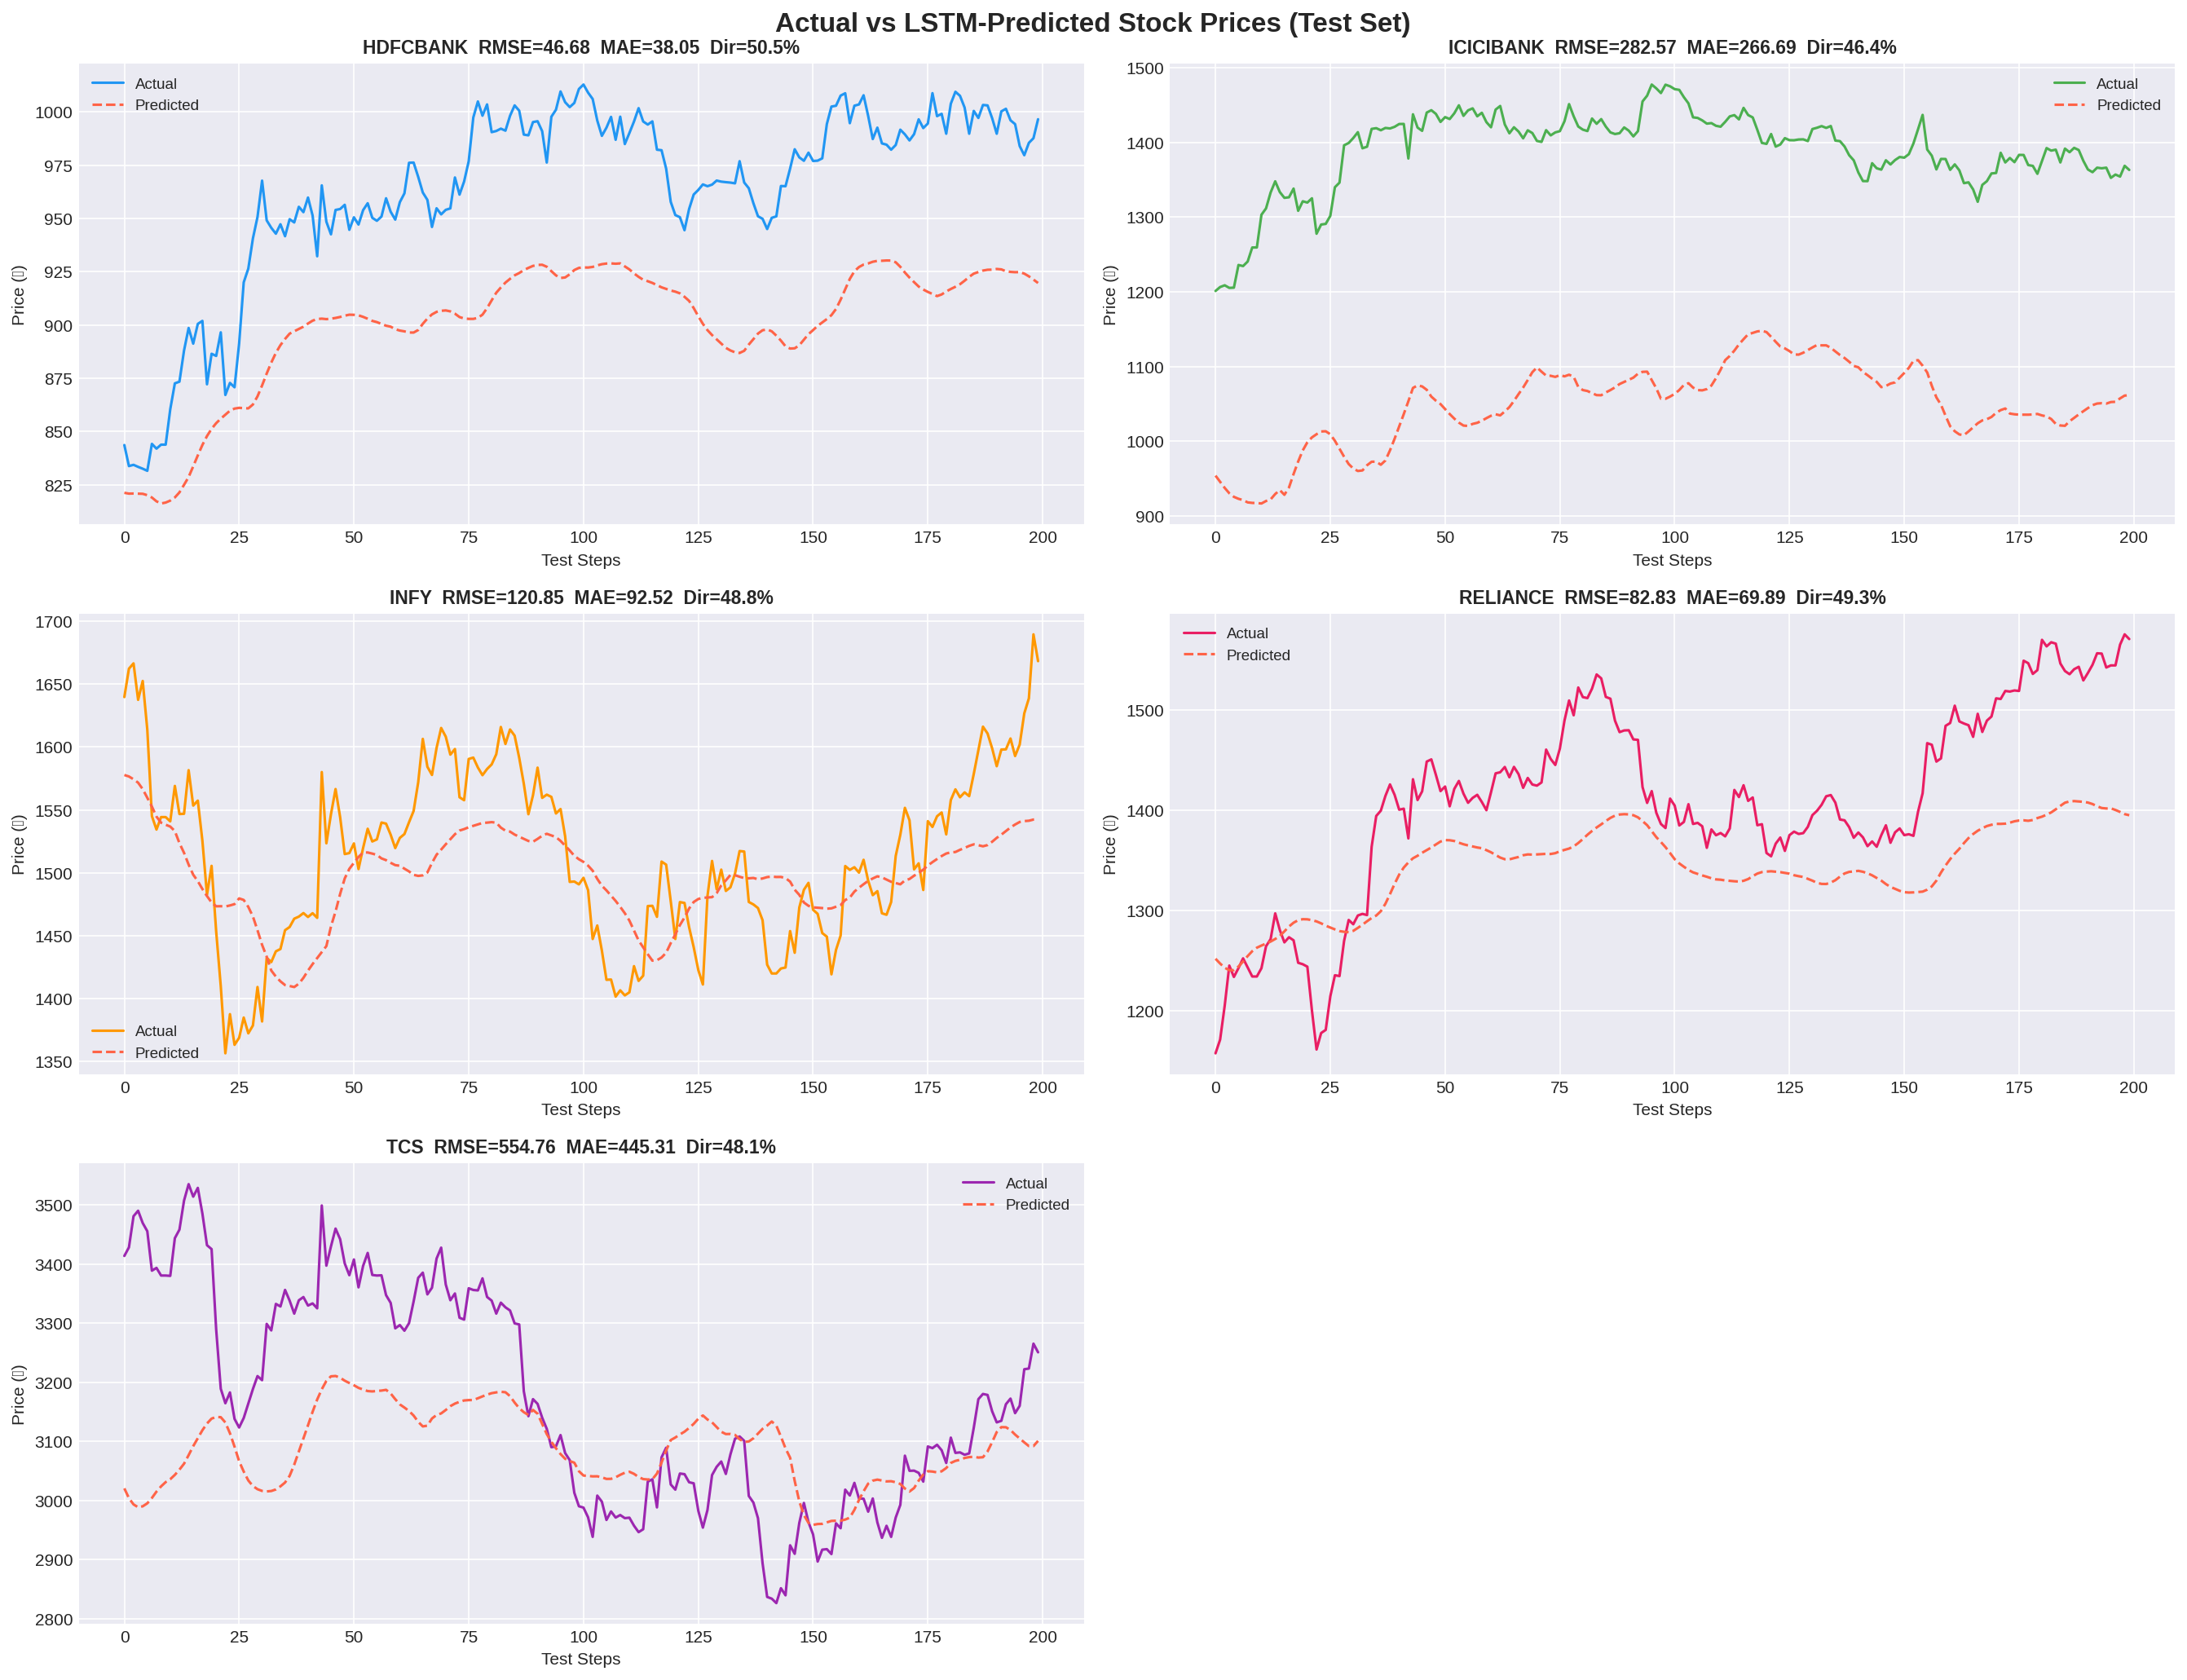

Showing: 07_correlation_heatmap.png


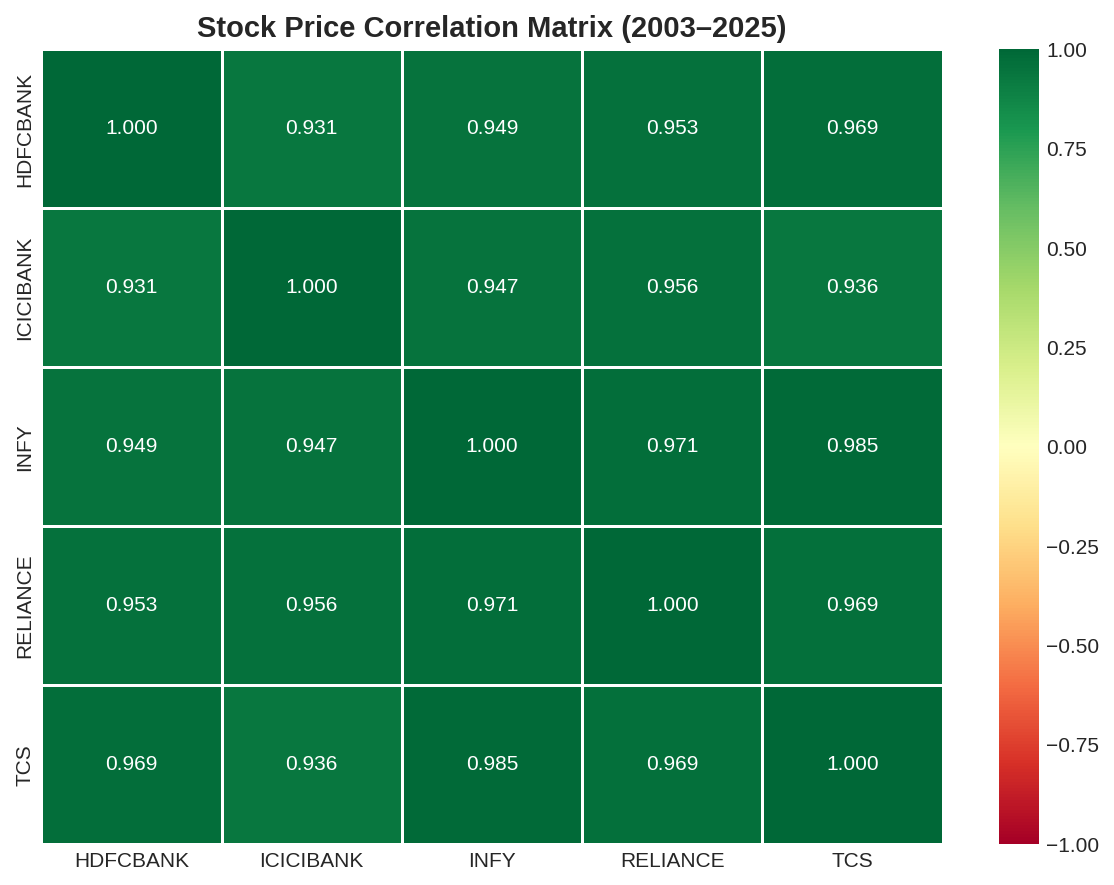

Showing: 03_technical_indicators.png


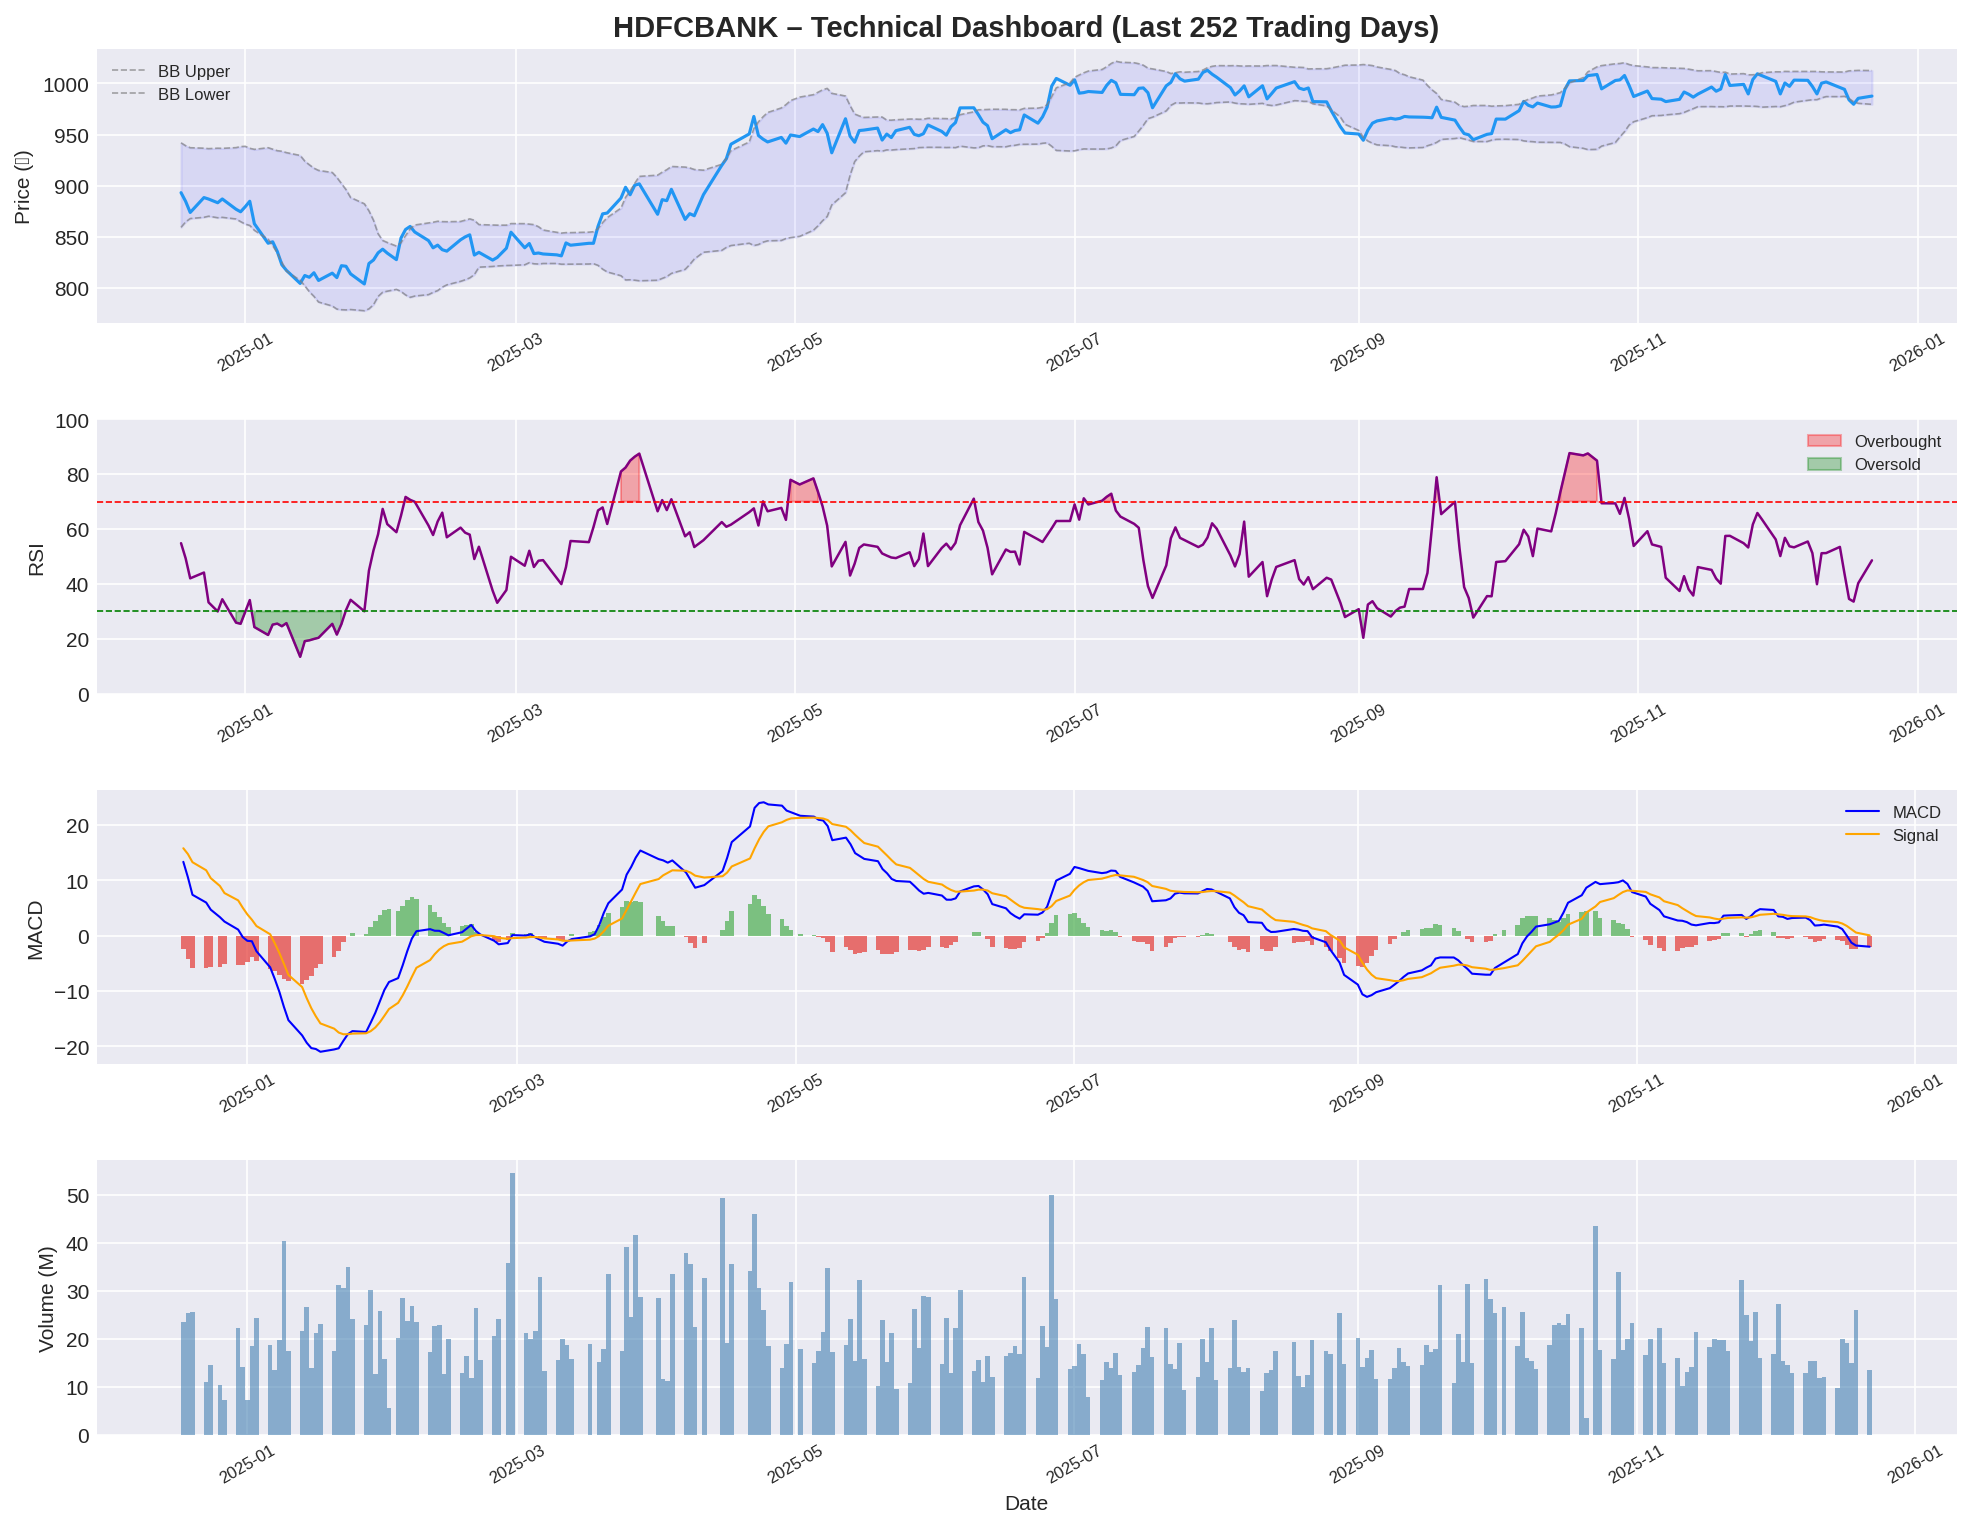

Showing: 05_risk_dashboard.png


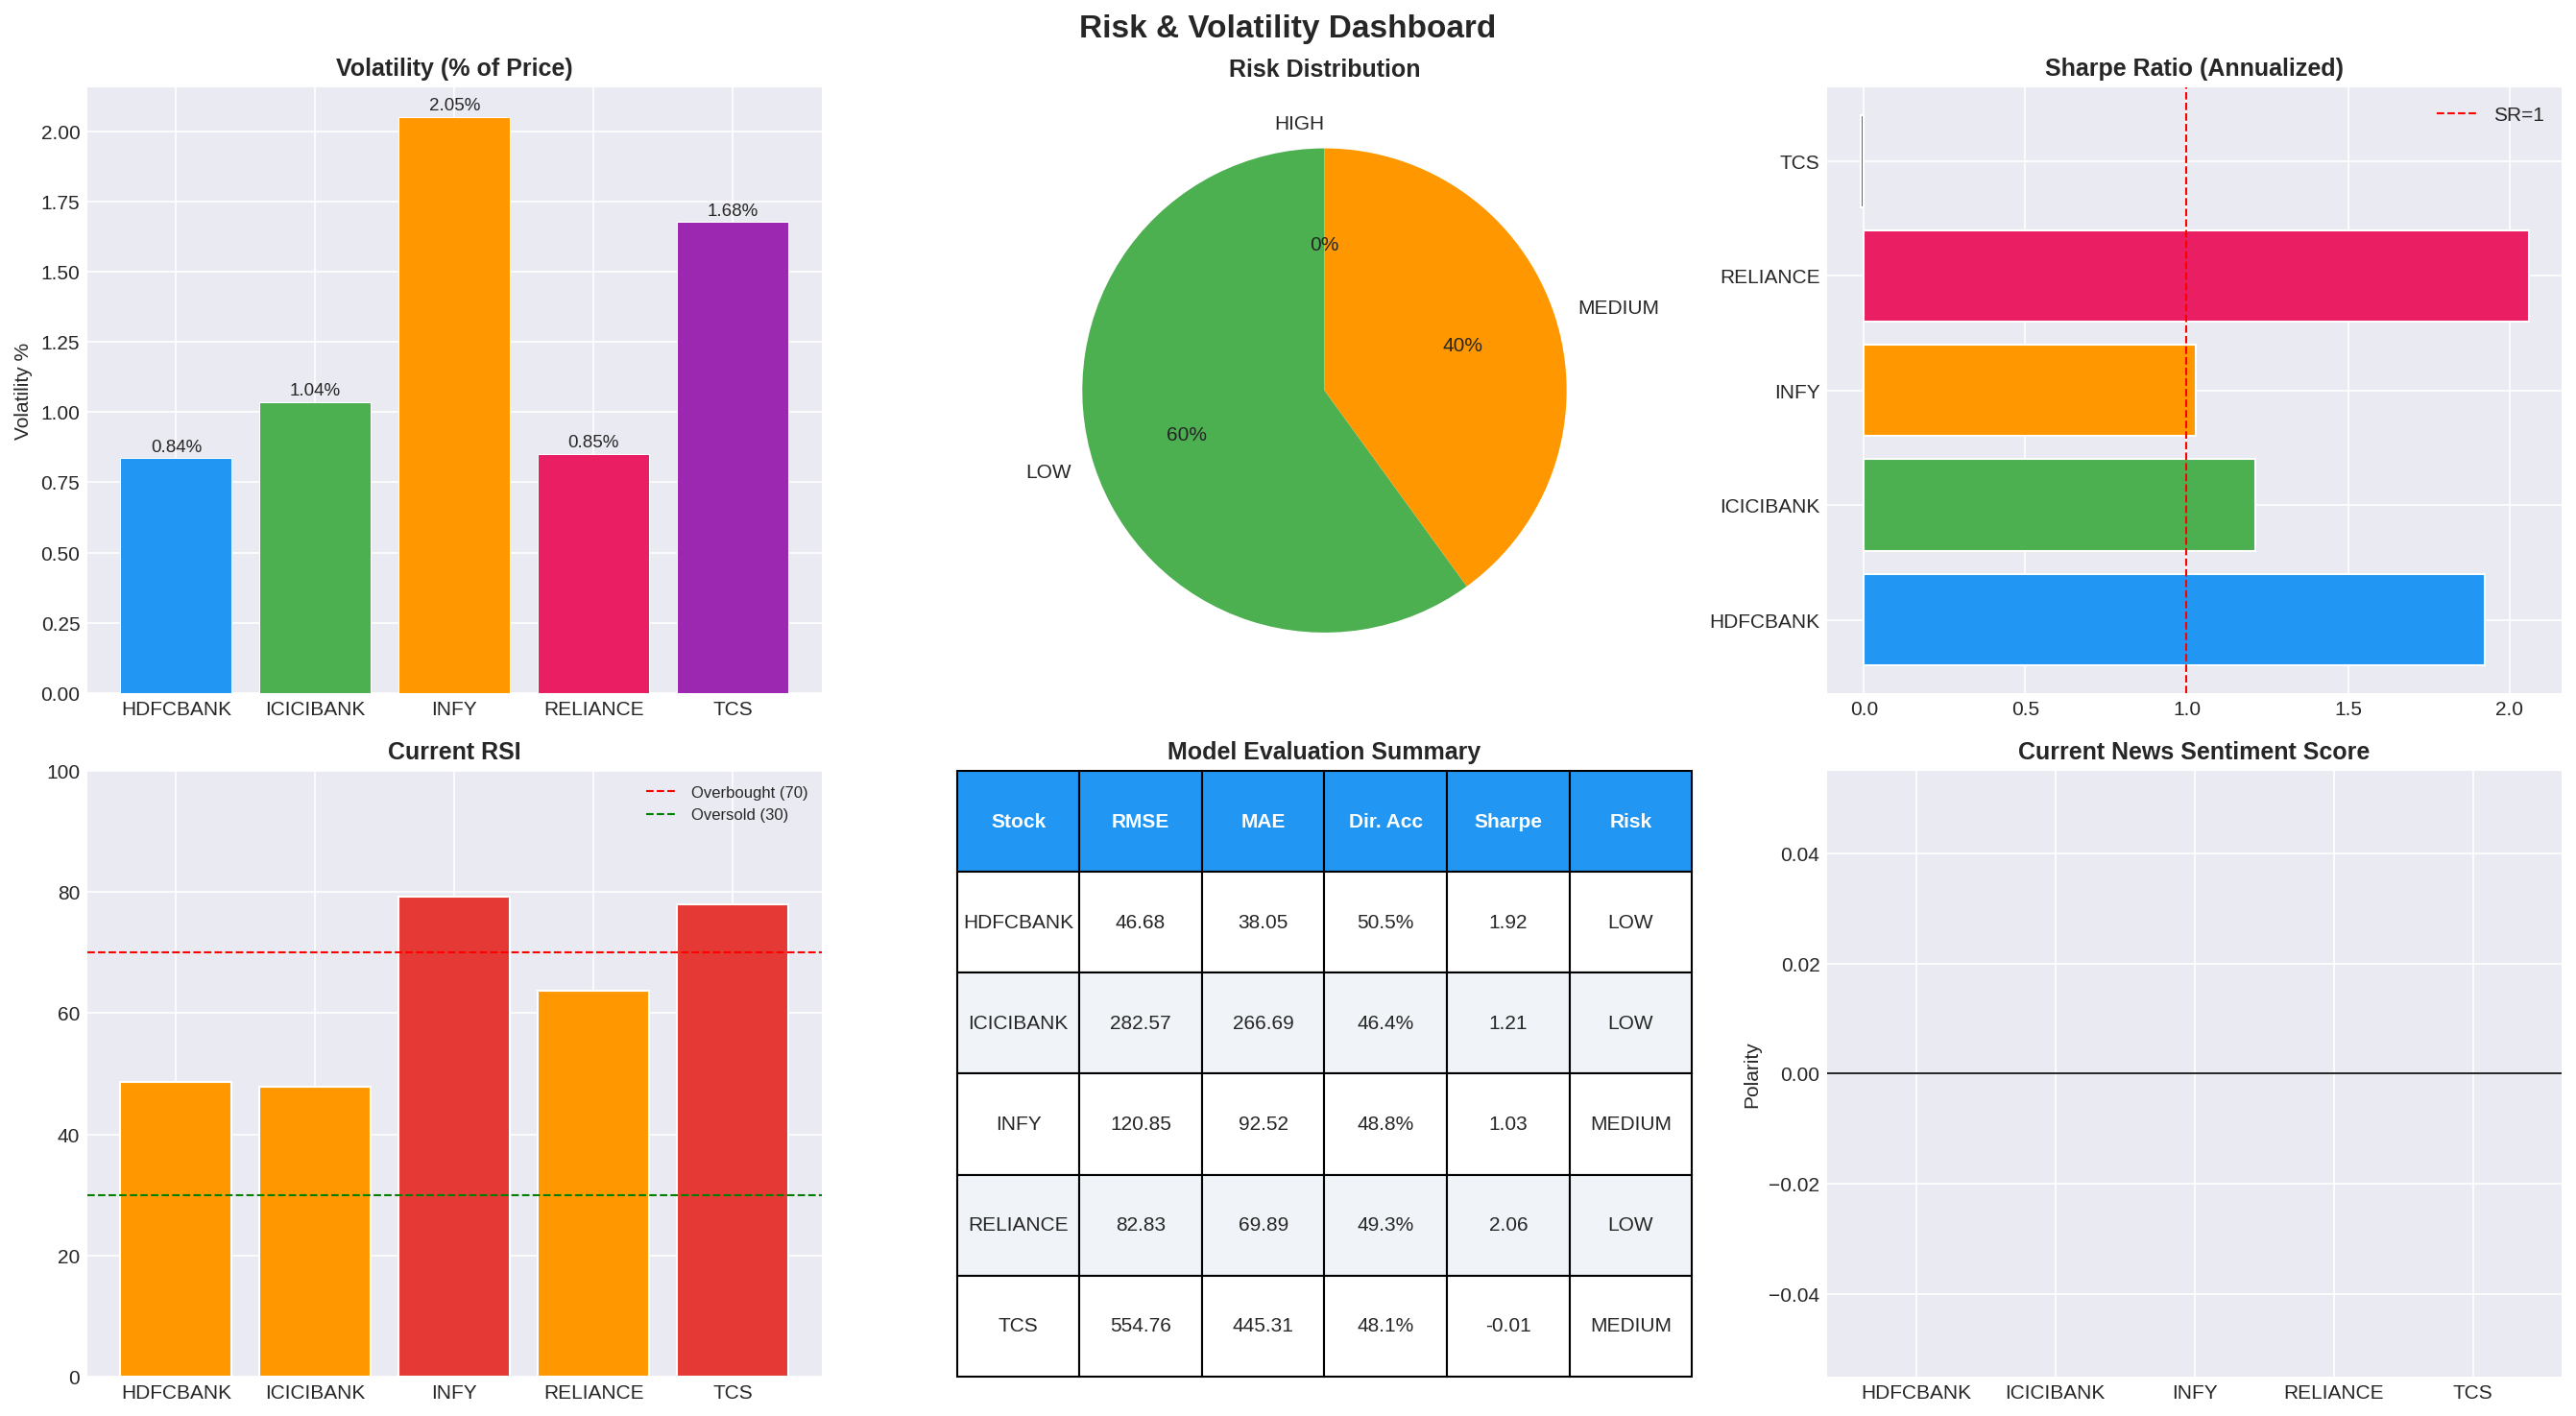

In [11]:
import os
from IPython.display import Image, display

output_path = "/content/outputs"

files = os.listdir(output_path)

for file in files:
    if file.endswith(".png") or file.endswith(".jpg"):
        print(f"Showing: {file}")
        display(Image(filename=os.path.join(output_path, file)))